In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import classification_report
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import GaussianNB



In [2]:
# df_original = pd.read_csv('Children Recode_final.csv')
# df_original['Malnurished'] = df_original[['Underweight', 'Stunting', 'Wasting']].max(axis=1)
# df = df_original.drop(['Underweight', 'Stunting', 'Wasting'], axis = 1)
# df.head()

# X = df.drop(columns=['Malnurished'])
# y = df['Malnurished']

# # Train-test Split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state= 12)

# # Columns to scale
# columns_to_scale = ['Child_age', 'Age_first_sex', 'BMI', 'Mother_age_current', 'Mother_age_at_first_birth']
# scaler = StandardScaler()

# # Make copies of training and test sets
# X_train_scaled = X_train.copy()
# X_test_scaled = X_test.copy()

# # Scale only selected columns
# X_train_scaled[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
# X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

# # Apply SMOTE
# sm = SMOTE(random_state=42)
# X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)

# print("Before SMOTE:", Counter(y_train))
# print("After SMOTE:", Counter(y_train_sm))

# # Train Gaussian Naive Bayes
# nb = GaussianNB()
# nb.fit(X_train_sm, y_train_sm)

# # Predict and evaluate on the test set
# y_pred = nb.predict(X_test_scaled)

# print("Classification Report on Test Set:")
# print(classification_report(y_test, y_pred))

### Load Dataset

In [3]:
# Load Data
df_original = pd.read_csv('df.csv')
df_original['Malnurished'] = df_original[['Underweight', 'Stunting', 'Wasting']].max(axis=1)
df = df_original.drop(['Underweight', 'Stunting', 'Wasting'], axis = 1)

# Train-test Split
X = df.drop(columns=['Malnurished'])
y = df['Malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, stratify = y, random_state = 42)

# Standard Scaler
columns_to_scale = ['Child_age', 'BMI', 'Mother_age_current']
scaler = StandardScaler()
X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [4]:
print(df.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(2205, 37)
Malnurished
0    1168
1     596
Name: count, dtype: int64
Malnurished
0    292
1    149
Name: count, dtype: int64


In [5]:
cont_cols = ['Child_age', 'BMI', 'Mother_age_current']
bin_cols = ['Mother_education_1', 'Mother_education_2',
       'Mother_education_3', 'Wealth_index_1', 'Wealth_index_2',
       'Wealth_index_3', 'Wealth_index_4', 'Place_residence_rural',
       'Region_madhesh province', 'Region_bagmati province',
       'Region_gandaki province', 'Region_lumbini province',
       'Region_karnali province', 'Region_sudurpashchim province',
       'Religion_buddhist', 'Religion_muslim', 'Religion_kirat',
       'Religion_christian', 'Ethnicity_hill chhetri',
       'Ethnicity_terai brahmin/chhetri', 'Ethnicity_other terai caste',
       'Ethnicity_hill dalit', 'Ethnicity_terai dalit', 'Ethnicity_newar',
       'Ethnicity_hill janajati', 'Ethnicity_terai janajati',
       'Child_sex_female', 'Father_education_1.0', 'Father_education_2.0',
       'Father_education_3.0', 'Health_insurance_yes']
ord_cols = ['Children_under5', 'Total_children_ever_born',]



In [6]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, CategoricalNB
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np

class HybridNaiveBayes(BaseEstimator, ClassifierMixin):
    def __init__(self, continuous_cols, binary_cols, ordinal_cols):
        """
        Parameters:
          continuous_cols (list): Names of columns with continuous features.
          binary_cols (list): Names of columns with binary features.
          ordinal_cols (list): Names of columns with ordinal categorical features.
        """
        self.continuous_cols = continuous_cols
        self.binary_cols = binary_cols
        self.ordinal_cols = ordinal_cols
        self.gnb = GaussianNB()
        self.bern_nb = BernoulliNB()
        self.cat_nb = CategoricalNB()
        
    def _encode_ordinal(self, X):
        # Copy ordinal columns and convert to 0-indexed if needed.
        X_ord = X[self.ordinal_cols].copy()
        for col in self.ordinal_cols:
            # If ordinal values start at 1, subtract 1 to make them 0-indexed.
            if X_ord[col].min() == 1:
                X_ord[col] = X_ord[col] - 1
        return X_ord

    def fit(self, X, y):
        # Separate the features by type.
        X_cont = X[self.continuous_cols]
        X_bin = X[self.binary_cols]
        X_ord = self._encode_ordinal(X)
        
        # Fit the respective classifiers.
        self.gnb.fit(X_cont, y)
        self.bern_nb.fit(X_bin, y)
        self.cat_nb.fit(X_ord, y)
        
        # Save the class labels.
        self.classes_ = self.gnb.classes_
        return self

    def predict_log_proba(self, X):
        # Split the features into their respective groups.
        X_cont = X[self.continuous_cols]
        X_bin = X[self.binary_cols]
        X_ord = self._encode_ordinal(X)
        
        # Calculate log probabilities.
        log_proba_cont = self.gnb.predict_log_proba(X_cont)
        log_proba_bin = self.bern_nb.predict_log_proba(X_bin)
        log_proba_ord = self.cat_nb.predict_log_proba(X_ord)
        
        # Combine by summing the log probabilities.
        return log_proba_cont + log_proba_bin + log_proba_ord

    def predict_proba(self, X):
        log_proba = self.predict_log_proba(X)
        proba = np.exp(log_proba)
        # Normalize probabilities to sum to 1.
        proba /= proba.sum(axis=1, keepdims=True)
        return proba

    def predict(self, X):
        log_proba = self.predict_log_proba(X)
        return self.classes_[np.argmax(log_proba, axis=1)]



### SMOTE Balancing

In [ ]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

## Model Fit

In [8]:
hybrid_nb = HybridNaiveBayes(
    continuous_cols=cont_cols,
    binary_cols=bin_cols,
    ordinal_cols=ord_cols
)
hybrid_nb.fit(X_train, y_train)

# Make predictions on the test set.
y_pred = hybrid_nb.predict(X_test)

# Evaluate the model.
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.60      0.66       292
           1       0.42      0.58      0.49       149

    accuracy                           0.59       441
   macro avg       0.58      0.59      0.58       441
weighted avg       0.63      0.59      0.60       441



### Average Precision

In [9]:
from sklearn.metrics import average_precision_score
print(f'Average Precision: {average_precision_score(y_test, y_pred)}')


Average Precision: 0.38838789949329433


In [10]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    hybrid_nb,
    X_test,
    y_test, 
    name="Naive",
    plot_chance_level = True,
    despine = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

ValueError: Expected 'estimator' to be a binary classifier. Got HybridNaiveBayes instead.

### Threshold Adjustment

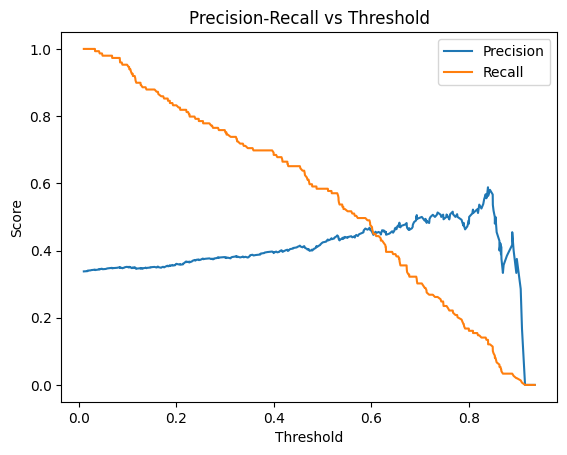

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

y_probas = hybrid_nb.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.show()

In [ ]:
y_probas = hybrid_nb.predict_proba(X_test)[:, 1]  

# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)

print(f'Confusion Matrix: \n{pd.crosstab(y_test, y_probas_custom)}\n')
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Confusion Matrix: 
col_0          0    1
Malnurished          
0            134  158
1             47  102

Classification Report: 
              precision    recall  f1-score   support

           0       0.74      0.46      0.57       292
           1       0.39      0.68      0.50       149

    accuracy                           0.54       441
   macro avg       0.57      0.57      0.53       441
weighted avg       0.62      0.54      0.54       441




## Optional

### ROC-AOC Curve

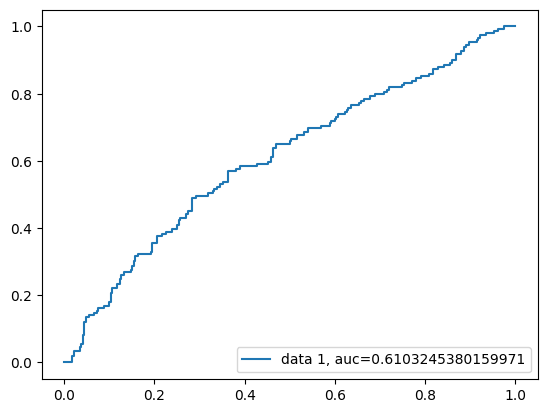

In [ ]:
from sklearn import metrics

y_probas_custom = hybrid_nb.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_probas_custom)
auc = metrics.roc_auc_score(y_test, y_probas_custom)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

1. Continuous predictors were supposed to be Gussian